In [13]:
# ==========================================
# Jupyter 환경에서 한글 폰트 직접 등록 (NanumGothic, URL 안정 버전)
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os, urllib.request

# 1️⃣ 폰트 저장 경로 설정
font_dir = "/home/user/.fonts"
os.makedirs(font_dir, exist_ok=True)
font_path = os.path.join(font_dir, "NanumGothic.ttf")

# 2️⃣ 안정적인 다운로드 URL (Google Fonts CDN)
font_url = (
    "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
)

if not os.path.exists(font_path):
    print("📦 나눔고딕 폰트 다운로드 중...")
    urllib.request.urlretrieve(font_url, font_path)
    print("✅ 나눔고딕 폰트 다운로드 및 저장 완료")
else:
    print("✅ 이미 나눔고딕 폰트가 존재합니다.")

# 3️⃣ 폰트 등록 및 적용
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print(f"🎨 현재 적용된 폰트: {plt.rcParams['font.family']}")

📦 나눔고딕 폰트 다운로드 중...
✅ 나눔고딕 폰트 다운로드 및 저장 완료
🎨 현재 적용된 폰트: ['NanumGothic']


In [15]:
# ==========================================
# [1] 데이터 불러오기
# ==========================================
import geopandas as gpd
import pandas as pd
import os

# 경로 설정
base_dir = "/home/user/ai/AnKiHyeon/공공데이터_원본/국토교통부_도로(현황)"
shp_path = os.path.join(base_dir, "C_UQ151.shp")

# 데이터 로드
roads = gpd.read_file(shp_path, encoding="euc-kr")

# 기본 정보 출력
print("✅ 데이터 로드 완료")
print(f"총 도로 수: {len(roads)}개")
print(f"좌표계: {roads.crs}")

# 컬럼명 및 타입 확인
display(
    pd.DataFrame(
        {"컬럼명": roads.columns, "데이터타입": [str(t) for t in roads.dtypes]}
    )
)

# 샘플 3개 확인
roads.head(3)

/home/user/venvs/AnKiHyeon_tensorflow/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: /home/user/ai/AnKiHyeon/공공데이터_원본/국토교통부_도로(현황)/C_UQ151.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


✅ 데이터 로드 완료
총 도로 수: 260743개
좌표계: EPSG:5174


,컬럼명,데이터타입
0,PRESENT_SN,object
1,LCLAS_CL,object
2,MLSFC_CL,object
3,SCLAS_CL,object
4,ATRB_SE,object
5,WTNNC_SN,object
6,NTFC_SN,object
7,DGM_NM,object
8,DGM_AR,float64
9,DGM_LT,float64


,PRESENT_SN,LCLAS_CL,MLSFC_CL,SCLAS_CL,ATRB_SE,WTNNC_SN,NTFC_SN,DGM_NM,DGM_AR,DGM_LT,SIGNGU_SE,GRAD_SE,ROAD_TY,ROAD_NO,ROAD_ROLE,DRAWING_NO,EXCUT_SE,CREATE_DAT,geometry
0,11000UQ151PS201912150255,UQS120,None,None,UQS120,11000URZ200112142887,11000NTC200112141790,소로1류,217.0,217.0,11000,소로,1,None,PMI0004,None,EMA0009,2019/12/14,"POLYGON ((211272.508 450363.816, 211266.5 4503..."
1,11000UQ151PS201912164933,UQS116,None,None,UQS116,11000URZ201801053484,11000NTC201801053007,대로3류,308.0,204.0,11000,대로,3,None,PMI0002,None,EMA0009,2019/12/14,"POLYGON ((201707.841 453572.994, 201699.55 453..."
2,11000UQ151PS201912155857,UQS190,None,None,UQS190,11000URZ000000001511,None,기타도로시설,1592.0,285.0,11000,None,None,None,None,None,EMA0009,2019/12/14,"POLYGON ((192022.365 445683.446, 192009.003 44..."


📐 좌표계 EPSG:5174 (미터 단위) → 변환 불필요

📊 도로 면적·길이 기본 통계


,area_m2,length_m,length_km
count,2.607430e+05,260743.000000,260743.000000
mean,7.848685e+03,919.827735,0.919828
std,4.322092e+04,2984.159622,2.984160
min,1.200000e-05,0.017525,0.000018
25%,5.644306e+02,182.612737,0.182613
50%,1.257203e+03,334.545049,0.334545
75%,3.296299e+03,681.858780,0.681859
max,2.755075e+06,325628.654883,325.628655


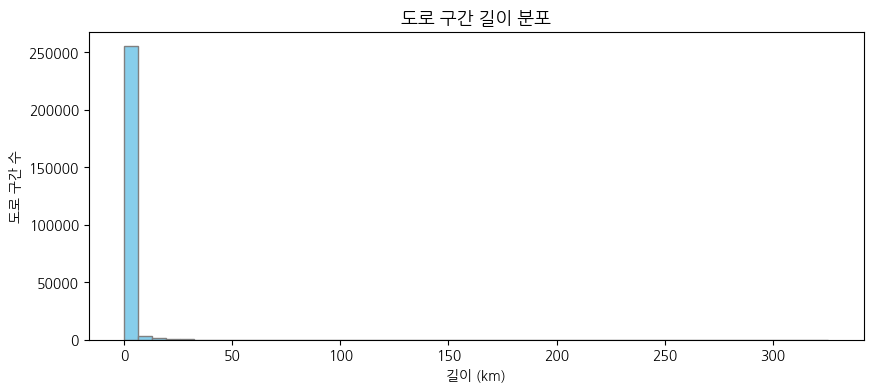

In [16]:
# ==========================================
# [2] 좌표계 확인 및 길이·면적 계산
# ==========================================

if str(roads.crs) == "EPSG:5174":
    print("📐 좌표계 EPSG:5174 (미터 단위) → 변환 불필요")
else:
    roads = roads.to_crs(epsg=5174)
    print("📏 좌표계를 EPSG:5174로 변환 완료")

# 면적(m²), 길이(m, km) 계산
roads["area_m2"] = roads.geometry.area
roads["length_m"] = roads.geometry.length
roads["length_km"] = roads["length_m"] / 1000

# 통계 확인
print("\n📊 도로 면적·길이 기본 통계")
display(roads[["area_m2", "length_m", "length_km"]].describe())

# 분포 확인용 히스토그램
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.hist(roads["length_km"], bins=50, color="skyblue", edgecolor="gray")
plt.title("도로 구간 길이 분포", fontsize=13)
plt.xlabel("길이 (km)")
plt.ylabel("도로 구간 수")
plt.show()

🔍 결측치 현황 상위 10개


,결측값 개수,결측률(%)
MLSFC_CL,245351,94.10
SCLAS_CL,244653,93.83
DRAWING_NO,221561,84.97
ROAD_ROLE,25769,9.88
CREATE_DAT,23273,8.93
ROAD_NO,21248,8.15
NTFC_SN,19511,7.48
ROAD_TY,11799,4.53
GRAD_SE,10908,4.18
EXCUT_SE,6540,2.51


🔁 중복 PRESENT_SN 개수: 2,012


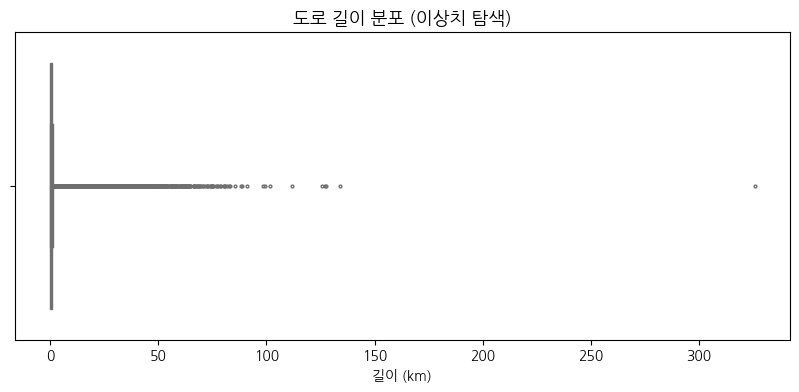

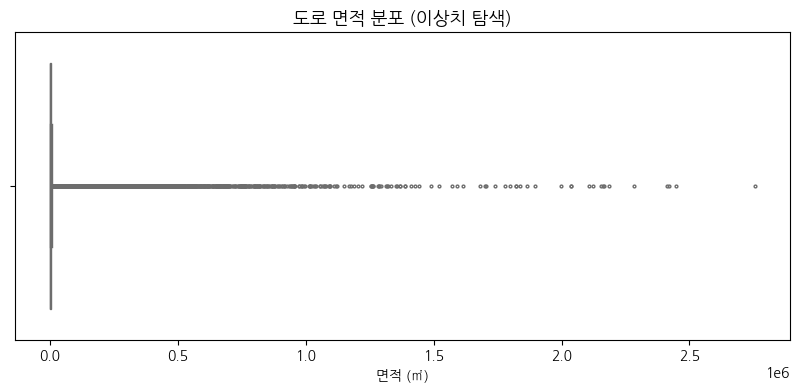

In [17]:
# ==========================================
# [3] 결측치 / 중복 / 이상치 탐색 및 시각화
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1️⃣ 결측치 비율 확인
missing = roads.isna().sum().sort_values(ascending=False)
missing_ratio = (missing / len(roads) * 100).round(2)
missing_df = pd.DataFrame({"결측값 개수": missing, "결측률(%)": missing_ratio})
print("🔍 결측치 현황 상위 10개")
display(missing_df.head(10))

# 2️⃣ 중복값 확인 (PRESENT_SN 기준)
dup_count = roads.duplicated(subset=["PRESENT_SN"]).sum()
print(f"🔁 중복 PRESENT_SN 개수: {dup_count:,}")

# 3️⃣ 이상치 시각화 - 길이
plt.figure(figsize=(10, 4))
sns.boxplot(data=roads, x="length_km", color="skyblue", fliersize=2)
plt.title("도로 길이 분포 (이상치 탐색)", fontsize=13)
plt.xlabel("길이 (km)")
plt.show()

# 4️⃣ 이상치 시각화 - 면적
plt.figure(figsize=(10, 4))
sns.boxplot(data=roads, x="area_m2", color="salmon", fliersize=2)
plt.title("도로 면적 분포 (이상치 탐색)", fontsize=13)
plt.xlabel("면적 (㎡)")
plt.show()

🚗 도로유형별 평균 길이·면적 요약:


,ROAD_TY,length_km,area_m2,count
281,정촌2,8.055362,32225.476369,1
316,통진1,6.805089,119293.479612,1
22,63,5.300348,94030.774091,1
195,시화3,5.247698,102604.713942,4
230,연성일1,4.883522,53289.500684,1
186,수동1,4.728505,23507.130535,2
307,집현1,4.324489,22056.606853,1
132,명석1,4.152403,18604.555937,2
308,집현2,4.141561,16579.358689,3
126,매산1,3.465708,34574.635495,1


/tmp/ipykernel_1796678/351897882.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_types, x="ROAD_TY", y="length_km", palette="Blues_d")


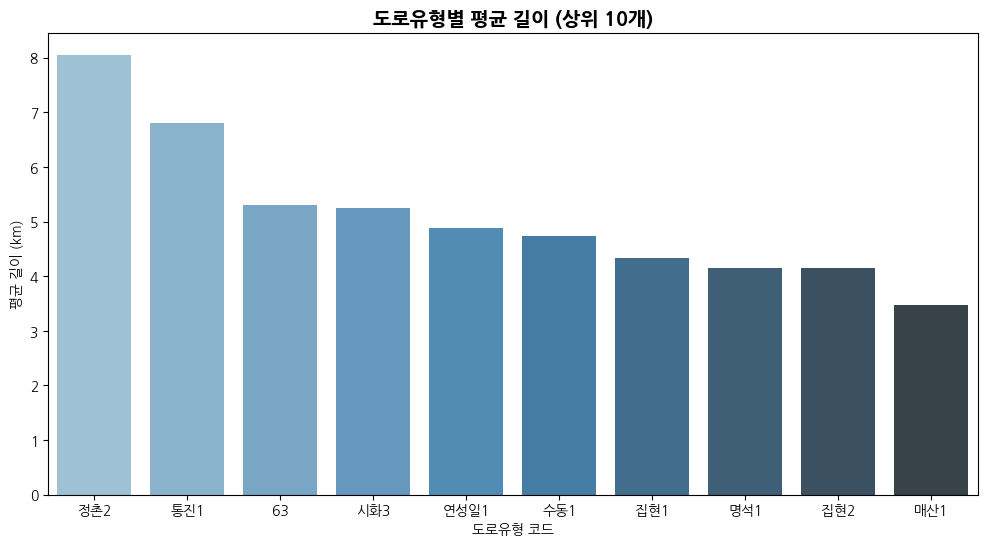

/tmp/ipykernel_1796678/351897882.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/user/venvs/AnKiHyeon_tensorflow/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


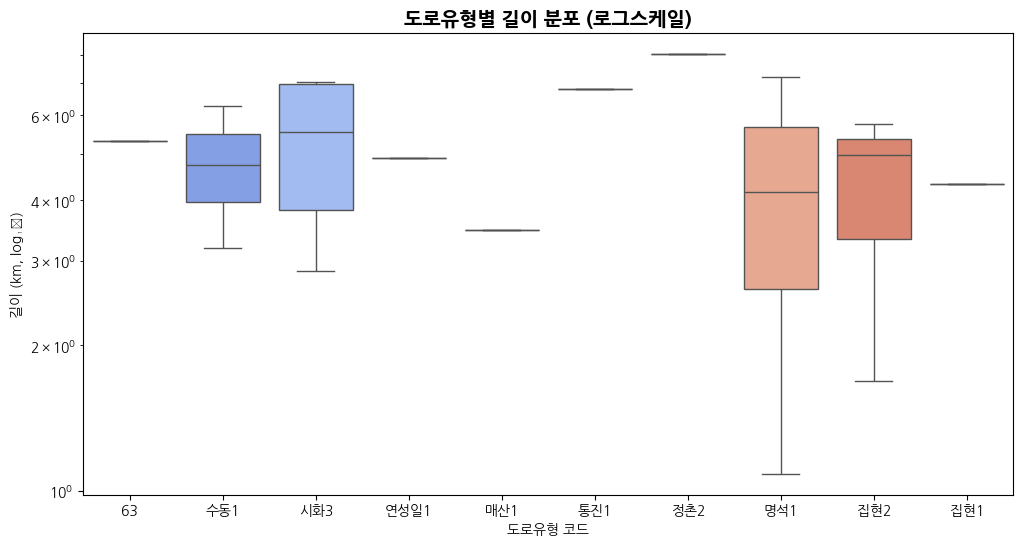

In [18]:
# ==========================================
# [4] 도로유형별 통계 및 분포 시각화
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

if "ROAD_TY" in roads.columns:
    # 1️⃣ 요약 통계 계산
    type_summary = (
        roads.groupby("ROAD_TY")[["length_km", "area_m2"]]
        .mean()
        .reset_index()
        .sort_values("length_km", ascending=False)
    )
    type_summary["count"] = (
        roads["ROAD_TY"].value_counts().reindex(type_summary["ROAD_TY"]).values
    )
    print("🚗 도로유형별 평균 길이·면적 요약:")
    display(type_summary.head(10))

    # 2️⃣ 평균 길이 barplot
    plt.figure(figsize=(12, 6))
    top_types = type_summary.head(10)
    sns.barplot(data=top_types, x="ROAD_TY", y="length_km", palette="Blues_d")
    plt.title("도로유형별 평균 길이 (상위 10개)", fontsize=14, weight="bold")
    plt.xlabel("도로유형 코드")
    plt.ylabel("평균 길이 (km)")
    plt.show()

    # 3️⃣ 길이 분포 boxplot (로그스케일)
    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=roads[roads["ROAD_TY"].isin(top_types["ROAD_TY"])],
        x="ROAD_TY",
        y="length_km",
        palette="coolwarm",
    )
    plt.yscale("log")  # 이상치 완화
    plt.title("도로유형별 길이 분포 (로그스케일)", fontsize=14, weight="bold")
    plt.xlabel("도로유형 코드")
    plt.ylabel("길이 (km, log₁₀)")
    plt.show()
else:
    print("⚠️ ROAD_TY 컬럼이 존재하지 않습니다.")

🏙️ 행정구역별 도로 총연장 상위 10개:


,SIGNGU_SE,length_km
0,11000,13953.808644
1,26000,7150.362285
3,28000,7116.657803
2,27000,5831.602288
6,31000,4989.969545
4,29000,4808.732182
128,50000,4778.230421
5,30000,4731.839245
110,48120,4164.990433
31,41590,4144.923944


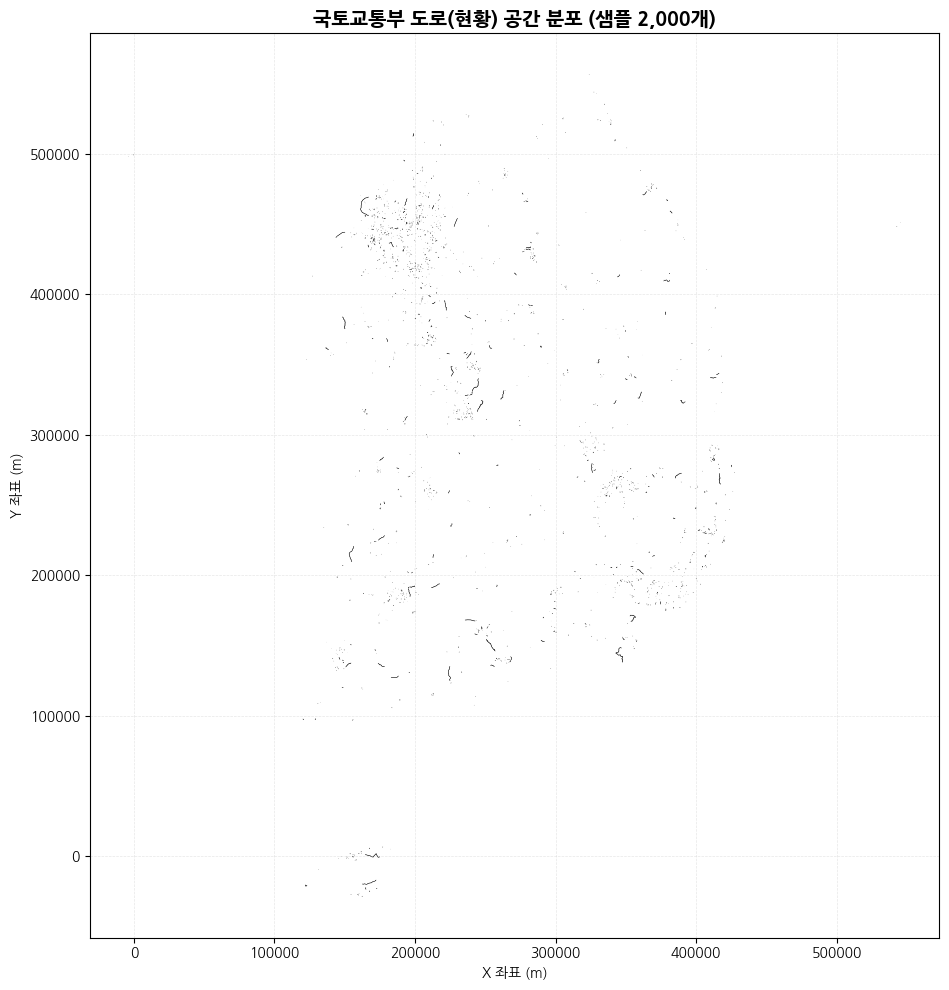

In [21]:
# ==========================================
# [5] 행정구역별 도로 총연장 분석 및 정적 지도 시각화
# ==========================================
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# 1️⃣ 행정구역별 총연장 계산
sigungu_summary = (
    roads.groupby("SIGNGU_SE")[["length_km"]]
    .sum()
    .reset_index()
    .sort_values("length_km", ascending=False)
)
print("🏙️ 행정구역별 도로 총연장 상위 10개:")
display(sigungu_summary.head(10))

# 2️⃣ 도로 중심점 지도 시각화 (샘플링)
roads_sample = roads.sample(2000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 10))
roads_sample.plot(
    ax=ax,
    color="#E0E0E0",
    edgecolor="#4B4B4B",
    linewidth=0.3,
)

ax.set_title(
    "국토교통부 도로(현황) 공간 분포 (샘플 2,000개)", fontsize=14, weight="bold"
)
ax.set_xlabel("X 좌표 (m)")
ax.set_ylabel("Y 좌표 (m)")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
import plotly.express as px

roads_sample = roads.sample(5000, random_state=42).to_crs(epsg=4326)

fig = px.scatter_mapbox(
    roads_sample,
    lat=roads_sample.geometry.centroid.y,
    lon=roads_sample.geometry.centroid.x,
    color="ROAD_TY",
    color_continuous_scale="Viridis",
    size_max=3,
    zoom=6,
    title="국토교통부 도로(현황) 공간 분포 (Plotly Express)",
)
fig.update_layout(
    mapbox_style="carto-positron", margin={"r": 0, "t": 40, "l": 0, "b": 0}
)
fig.show()

/tmp/ipykernel_1796678/3356406558.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lat=roads_sample.geometry.centroid.y,
/tmp/ipykernel_1796678/3356406558.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lon=roads_sample.geometry.centroid.x,
/tmp/ipykernel_1796678/3356406558.py:5: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


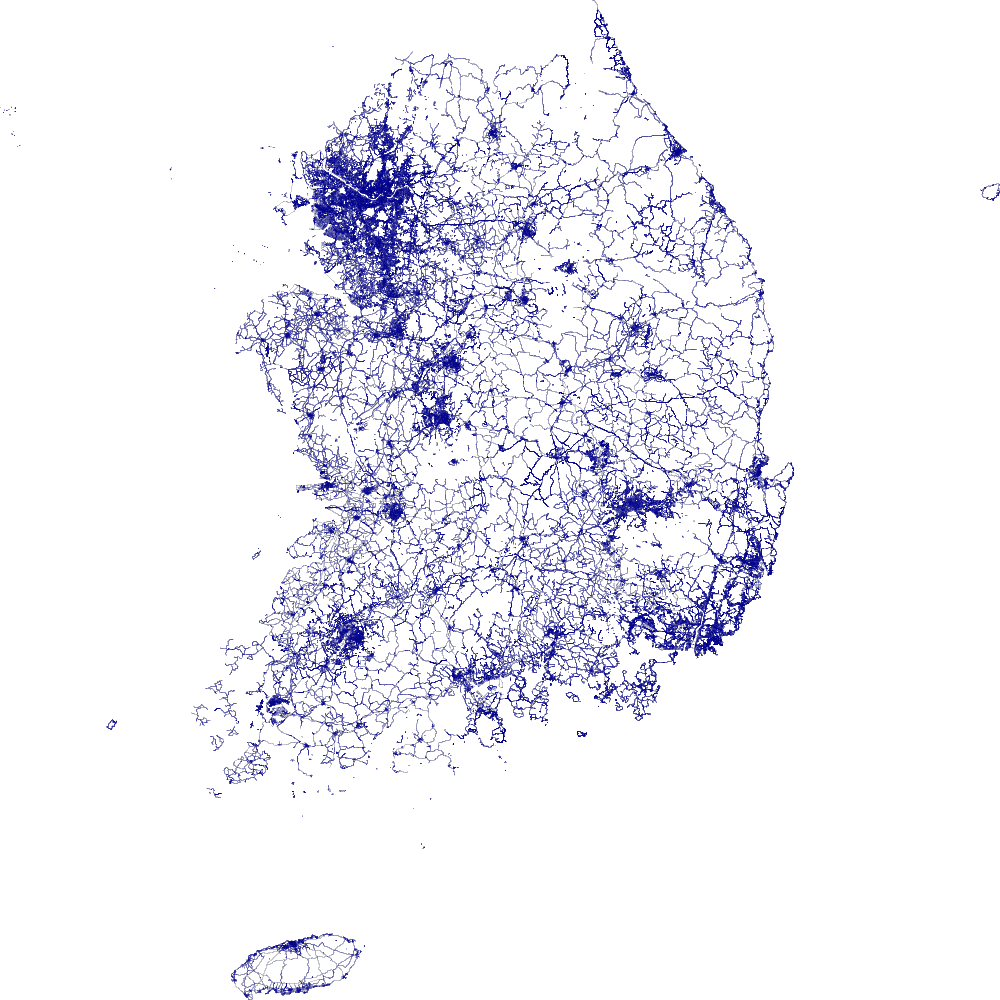

In [27]:
import datashader as ds
import datashader.transfer_functions as tf
from datashader.utils import export_image
from datashader import reductions as rd
import geopandas as gpd

roads_proj = roads.to_crs(epsg=5179)
canvas = ds.Canvas(plot_width=1000, plot_height=1000)
agg = canvas.line(roads_proj, geometry="geometry", agg=rd.count())
img = tf.shade(agg, cmap=["lightgray", "darkblue"])
tf.set_background(img, "white")
img

In [28]:
# ==========================================
# [Plotly Express] 전체 도로 대화형 시각화
# ==========================================
import geopandas as gpd
import plotly.express as px

# ---------------------------
# 1️⃣ 데이터 준비
# ---------------------------
# CRS 확인 및 변환 (WGS84: EPSG 4326)
if roads.crs is None or roads.crs.to_epsg() != 4326:
    roads_wgs = roads.to_crs(epsg=4326)
else:
    roads_wgs = roads.copy()

# 너무 많으면 브라우저가 느려질 수 있으므로 적절히 샘플링 (예: 10,000개)
roads_vis = roads_wgs.sample(10000, random_state=42)

# 위도·경도 중심 좌표 계산
roads_vis["lon"] = roads_vis.geometry.centroid.x
roads_vis["lat"] = roads_vis.geometry.centroid.y

# ---------------------------
# 2️⃣ 대화형 지도 생성
# ---------------------------
fig = px.scatter_mapbox(
    roads_vis,
    lat="lat",
    lon="lon",
    color="ROAD_TY",  # 도로유형별 색상 구분
    hover_name="DGM_NM",  # 도로명 표시
    hover_data={
        "SIGNGU_SE": True,
        "length_km": True,
        "area_m2": False,
    },
    color_continuous_scale="Viridis",
    zoom=6,
    title="국토교통부 도로(현황) 공간 분포 (ROAD_TY 기준)",
    height=800,
)

# ---------------------------
# 3️⃣ 지도 스타일 설정
# ---------------------------
fig.update_layout(
    mapbox_style="carto-positron",
    margin={"r": 0, "t": 40, "l": 0, "b": 0},
    coloraxis_colorbar=dict(title="도로유형(ROAD_TY)"),
)

# ---------------------------
# 4️⃣ 표시
# ---------------------------
fig.show()

/tmp/ipykernel_1796678/3781191090.py:20: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


/tmp/ipykernel_1796678/3781191090.py:21: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


/tmp/ipykernel_1796678/3781191090.py:26: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

